# **Студент:** Русаков Егор Константинович

**Группа: 6**

**Задача хакатона. ChemAI: Predict the Cure**

### **Проблема:**

Разработка новых лекарственных препаратов — сложный и длительный процесс, включающий синтез соединений и их биологическое тестирование. Современные методы машинного обучения позволяют ускорить этот процесс, предсказывая эффективность химических соединений до проведения лабораторных экспериментов. В этом соревновании вам предстоит выступить в роли ML и Data-инженеров в команде фармацевтической разработки. Химики предоставили данные о свойствах молекул и их биологической активности против вируса гриппа. Ваша задача — построить модели, способные предсказывать эффективность новых соединений.

### **Оценивание:**

Задача оценивается по метрике RMSE (Root Mean Squared Error), усреднённый по трём таргетам:

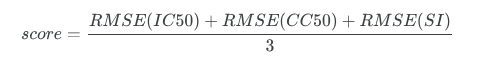

### **Данные:**

Данные разделены на:

    train.csv — 750 объектов с известными значениями целевых переменных
    test.csv — 250 объектов, для которых необходимо сделать предсказания


В обучающей выборке представлены три целевые переменные:

*   IC50 — концентрация вещества, при которой подавляется 50% биологической активности
*   CC50 — концентрация, при которой наблюдается токсичность для 50% клеток
*   SI (Selectivity Index) — индекс селективности, характеризующий эффективность соединени

**Обратите внимание:** SI связан с IC50 и CC50, однако в рамках соревнования его необходимо предсказывать как отдельную переменную.


### **Features:**

В этой работе я попробую потыкать все группы признаков, а именно:



1.   **Общие молекулярные свойства** (MolWt, ExactMolWt, HeavyAtomMolWt, NumValenceElectrons, NumRadicalElectrons, MolLogP, MolMR, TPSA, LabuteASA)
2.   **Электронные и зарядовые характеристики** (MaxPartialCharge, MinPartialCharge, MaxAbsPartialCharge, MinAbsPartialCharge, PEOE_VSA* — дескрипторы, связанные с распределением электронной плотности)
3.   **Топологические и структурные дескрипторы** (Chi*, Kappa*, BalabanJ, BertzCT, HallKierAlpha, Ipc, FractionCSP3, RingCount)
4. **Поверхностные дескрипторы** (VSA) (SMR_VSA*, SlogP_VSA*, EState_VSA*, VSA_EState*, ...)

5. **Функциональные группы (fr_*)** (Бинарные признаки, отражающие наличие различных химических групп: fr_alkyl_halide, fr_ester, fr_ether, fr_ketone, fr_benzene, fr_pyridine, fr_imidazole, fr_amide, fr_amine, fr_nitro, fr_halogen и многие другие)

6. **Специфические дескрипторы** (EState индексы (MaxEStateIndex, MinEStateIndex и др.), BCUT2D_* — спектральные дескрипторы, FpDensityMorgan* — плотности молекулярных отпечатков.


И помимо прочего попробую создать:

*   **одну multi-target модель**
*   **отдельные модели для каждой группы переменной**

Потом проверим, что из этого лучше.



### **План работы:**

1.   **Загрузка данных и библиотек**
2.   *Анализ данных*
3.   **Предобработка данных**
4.   *Feature Engineering*
5.   **Encoding и scaling**
6.   *Обучение моделей, эксперименты, гиперпараметры*


# **Загрузка данных и библиотек**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки графиков
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

from sklearn.preprocessing import RobustScaler

from sklearn.model_selection import KFold
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import PowerTransformer

import itertools

In [2]:
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

print(f"Обучающая выборка (train_df): {train_df.shape[0]} строк, {train_df.shape[1]} колонок")
print(f"Тестовая выборка (test_df): {test_df.shape[0]} строк, {test_df.shape[1]} колонок")

Обучающая выборка (train_df): 751 строк, 214 колонок
Тестовая выборка (test_df): 250 строк, 211 колонок


# **Анализ данных**

In [3]:
train_df.head(7)

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0
5,5,79.446857,204.395096,2.572727,13.227850,13.227850,0.101702,-4.536018,0.803563,27.100000,...,0,0,0,0,0,0,0,0,0,0
6,6,83.319304,1426.700413,17.123288,11.074198,11.074198,0.094066,-0.728054,0.896573,34.960000,...,0,0,0,0,0,0,0,0,0,0


In [4]:
train_df.shape

(751, 214)

**Посмотрим распределение таргета:**

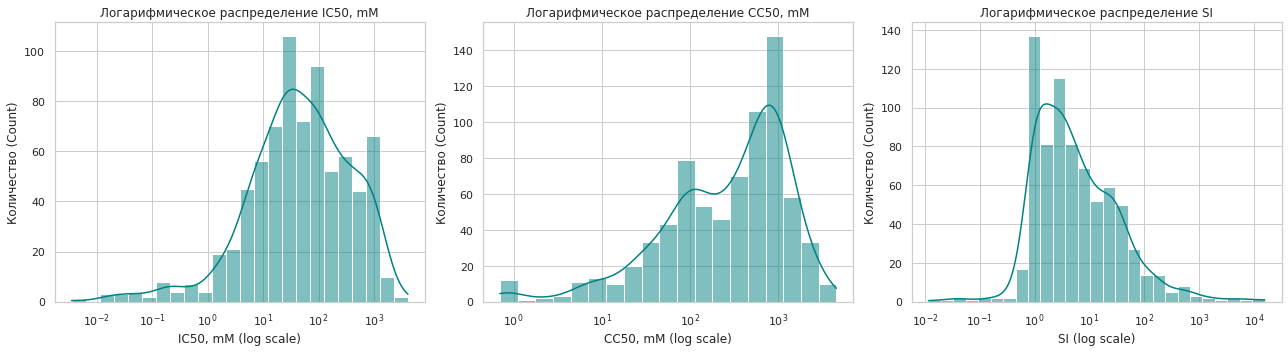

In [5]:
target_cols = ['IC50, mM', 'CC50, mM', 'SI']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(target_cols):
    # Используем log_scale=True, потому-что преобразуем шкалу графика в логарифмичекий масштаб для удобства визуализации
    sns.histplot(data=train_df, x=col, kde=True, ax=axes[i], color='teal', log_scale=True)
    axes[i].set_title(f"Логарифмическое распределение {col}")
    axes[i].set_xlabel(f"{col} (log scale)")
    axes[i].set_ylabel("Количество (Count)")

plt.tight_layout()
plt.show()

На графиках в линейном масштабе ничего не было видно из-за огромного разброса: медиана индекса селективности равна 4, а максимум улетает за 15 тысяч. Из-за таких единичных гигантских значений вся основная масса данных просто сжалась в одну нечитаемую полосу у нуля. Я перевел графики в логарифмический масштаб, чтобы сжать этот тяжелый хвост выбросов и нормально разглядеть структуру данных.

В итоге по графикам видно, что распределение IC50 четко делится на два пика. Это значит, что в датасете есть два разных типа соединений - сильные, которым для борьбы с вирусом нужна микродоза, и слабые пустышки.

Распределение токсичности CC50 при этом смещено вправо, то есть вещества становятся опасными для клеток только при высоких концентрациях, что хорошо для будущего лекарства.

Сам индекс SI показал красивое распределение, где основная масса молекул имеет безопасный уровень от 1 до 10, но длинный правый хвост подсвечивает те самые редкие высокоэффективные соединения, которые нам и нужно научить модель находить. Для обучения моделей может быть таргет тоже нужно будет логарифмировать, чтобы минимизировать влияние этих гигантских скачков на ошибку.

In [6]:
# Обязательно делаем reshape(-1, 1), так как трансформер ждет матрицу
pt = PowerTransformer(method='yeo-johnson')

# Редуцируем распределение SI
# Это сгладит "тяжелые хвосты" и приведет данные к более нормальному виду
y_si_transformed = pt.fit_transform(train_df['SI'].values.reshape(-1, 1))

# Заменяем старый SI на трансформированный
train_df['SI'] = y_si_transformed 

**Посмотрим пустоты и дубликаты:**

In [7]:
missing_values = train_df.isna().sum()
total_missing = missing_values.sum()

print("=== Проверка на пропущенные значения ===")
if total_missing == 0:
    print("В датасете нет пропущенных значений. Все ячейки заполнены.")
else:
    # Показываем только те колонки, где реально есть пропуски
    print(f"Общее количество пропусков: {total_missing}")
    print(missing_values[missing_values > 0])

print("\n" + "="*50 + "\n")

cols_to_check = train_df.columns.drop('index') if 'index' in train_df.columns else train_df.columns
duplicate_count = train_df.duplicated(subset=cols_to_check).sum()

print("=== Проверка на дубликаты строк ===")
if duplicate_count == 0:
    print("Явных дубликатов строк в датасете не обнаружено.")
else:
    print(f"Обнаружено дубликатов строк: {duplicate_count}")

=== Проверка на пропущенные значения ===
Общее количество пропусков: 24
MaxPartialCharge       2
MinPartialCharge       2
MaxAbsPartialCharge    2
MinAbsPartialCharge    2
BCUT2D_MWHI            2
BCUT2D_MWLOW           2
BCUT2D_CHGHI           2
BCUT2D_CHGLO           2
BCUT2D_LOGPHI          2
BCUT2D_LOGPLOW         2
BCUT2D_MRHI            2
BCUT2D_MRLOW           2
dtype: int64


=== Проверка на дубликаты строк ===
Обнаружено дубликатов строк: 15


In [8]:
# Список префиксов, по которым нужно исключить столбцы
prefixes = ('fr_', 'VSA_', 'Chi_', 'Kappa_')

# Точные имена столбцов для исключения
exact_names = ['index', 'IC50, mM', 'CC50, mM', 'SI']

# Находим все столбцы, начинающиеся с любого из префиксов
cols_to_drop_by_prefix = [col for col in train_df.columns 
                          if col.startswith(prefixes)]

# Объединяем точные имена и найденные по префиксам
cols_to_drop = exact_names + cols_to_drop_by_prefix

# Удаляем их из списка признаков
features_cols = train_df.columns.drop(cols_to_drop, errors='ignore')

**Посмотрим аномалии:**

In [9]:
# Исключаем колонку 'index' и наши таргеты, чтобы анализировать только признаки

outliers_summary = []

for col in features_cols:
    # Проверяем только числовые признаки
    if pd.api.types.is_numeric_dtype(train_df[col]):
        Q1 = train_df[col].quantile(0.15)
        Q3 = train_df[col].quantile(0.85)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Считаем количество строк, выпавших за границы
        outliers_count = train_df[(train_df[col] < lower_bound) | (train_df[col] > upper_bound)].shape[0]
        outliers_percentage = (outliers_count / train_df.shape[0]) * 100

        if outliers_count > 0:
            outliers_summary.append({
                'Признак': col,
                'Кол-во выбросов': outliers_count,
                'Процент выбросов (%)': round(outliers_percentage, 2)
            })

# Превращаем в датафрейм и сортируем по убыванию количества аномалий
outliers_df = pd.DataFrame(outliers_summary).sort_values(by='Кол-во выбросов', ascending=False)

print(f"Всего признаков с выбросами: {len(outliers_df)} из {len(features_cols)}")
print("\nТоп-15 признаков по количеству аномалий:")
print(outliers_df.head(15).to_string(index=False))

Всего признаков с выбросами: 76 из 115

Топ-15 признаков по количеству аномалий:
     Признак  Кол-во выбросов  Процент выбросов (%)
         Ipc              107                 14.25
 SlogP_VSA11               85                 11.32
  PEOE_VSA12               55                  7.32
    SMR_VSA9               51                  6.79
  SlogP_VSA7               42                  5.59
   PEOE_VSA3               31                  4.13
 BCUT2D_MWHI               30                  3.99
BCUT2D_MRLOW               28                  3.73
  PEOE_VSA11               23                  3.06
EState_VSA11               21                  2.80
  PEOE_VSA10               20                  2.66
   NHOHCount               17                  2.26
  NumHDonors               17                  2.26
   PEOE_VSA1               14                  1.86
       Chi3n               14                  1.86


 Ipc опологический индекс растет экспоненциально. Его огромные значения — это не ошибка, а просто признак крупных или сильно разветвленных молекул. Обычный IQR-фильтр видит в них аномалию.

Высокий процент выбросов в топ-признаках объясняется самой природой химических данных. Большинство этих признаков - это скорее всего какие-то специфические структурные фрагменты молекул.

Что с этим делать? ответ: та ничего не нужно делать.

Пытаться чистить эти выбросы стандартными методами (удалять строки или жестко обрезать их по границам) категорически нельзя! Таким образом, мы просто уничтожим всю химическую информацию и потеряем четверть датасета.

Но можно:

- Использовать устойчивые к выбросам модели: Деревья решений и основанные на них ансамбли (LightGBM, XGBoost, CatBoost) абсолютно нечувствительны к таким выбросам в признаках. Они просто сделают сплит в нужной точке и аномальные значения никак не сломают им логику. На них и сделаем упор.

- Правильное масштабирование: Когда дойдем до этапа скалирования, вместо стандартного StandardScaler (который сходит с ума от выбросов, так как использует среднее и дисперсию) мы возьмем RobustScaler. Он масштабирует данные по медиане и межквартильному размаху, что идеально зайдет под наши фичи.

# **Предобработка данных**

В датасете было найдено 15 полных дубликатов строк по признакам. Мы полностью удалим их, чтобы исключить зазубривание моделью одинаковых молекул и предотвратить переобучение.

Во-вторых, мы выявили 24 пропущенных значения, которые были точечно распределены по электронным и зарядовым характеристикам. Учитывая сильные аномальные скачки в химических свойствах молекул, мы заполнили эти пустоты медианой по каждому признаку, так как она наиболее устойчива к выбросам.

In [10]:
# Запоминаем размер до удаления
shape_before_dup = train_df.shape[0]

# Удаляем полные дубликаты по признакам (исключая индекс и таргеты)
cols_to_check = train_df.columns.drop(['index', 'IC50, mM', 'CC50, mM', 'SI'], errors='ignore')
train_df = train_df.drop_duplicates(subset=cols_to_check, keep='first').reset_index(drop=True)

print(f"Удалено дубликатов строк: {shape_before_dup - train_df.shape[0]}")
print(f"Размер выборки после удаления дубликатов: {train_df.shape[0]} строк")

Удалено дубликатов строк: 121
Размер выборки после удаления дубликатов: 630 строк


In [11]:
# Колонки, в которых были обнаружены пропуски
cols_with_nas = [
    'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge',
    'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO',
    'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW'
]

# Заполняем пропуски медианными значениями, посчитанными по train_df
for col in cols_with_nas:
    median_value = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_value)

print("=== Проверка после заполнения пропусков ===")
print(f"Осталось пропусков в датасете: {train_df.isna().sum().sum()}")

=== Проверка после заполнения пропусков ===
Осталось пропусков в датасете: 0


In [12]:
## Логарифмируем Ipc в обучающей выборке
#if 'Ipc' in train_df.columns:
#    train_df['Ipc'] = np.log1p(train_df['Ipc'])
#    print("Признак 'Ipc' в train_df успешно прологарифмирован.")

# Точно так же логарифмируем Ipc в тестовой выборке
#if 'test_df' in globals() and 'Ipc' in test_df.columns:
#    test_df['Ipc'] = np.log1p(test_df['Ipc'])
#    print("Признак 'Ipc' в test_df успешно прологарифмирован.")

Признак 'Ipc' в train_df успешно прологарифмирован.
Признак 'Ipc' в test_df успешно прологарифмирован.


In [12]:
train_df.shape

(630, 214)

Да, предобработка оказалась короткой, но мне почему-то на ум именно в данный момент ничего более не приходит)))

# **Feature Engineering**

## Дисперсный фильтр. Проверка "мертвых" признаков

In [13]:
# 1. Служебные колонки и таргеты не участвуют в отборе
service_cols = ['index', 'IC50, mM', 'CC50, mM', 'SI']
feature_cols = [c for c in train_df.columns if c not in service_cols]

# 2. Создаём и обучаем селектор
selector = VarianceThreshold(threshold=0.005)
selector.fit(train_df[feature_cols])

# 3. Определяем признаки с низкой дисперсией (которые будут удалены)
# get_support() -> True для признаков с дисперсией >= порога
# Инвертируем, чтобы получить False для хороших и True для плохих
low_variance_mask = ~selector.get_support()

# Собираем имена признаков, где low_variance_mask == True
dropped_features = [feature_cols[i] for i, low_var in enumerate(low_variance_mask) if low_var]

# 4. Выводим результаты
print(f"=== АНАЛИЗ ДИСПЕРСИИ ===")
print(f"Всего признаков на проверке: {len(feature_cols)}")
print(f"Найдено признаков с низкой дисперсией: {len(dropped_features)}")
print("\nСписок этих признаков (в них почти везде одинаковые значения):")
print(dropped_features)

=== АНАЛИЗ ДИСПЕРСИИ ===
Всего признаков на проверке: 210
Найдено признаков с низкой дисперсией: 27

Список этих признаков (в них почти везде одинаковые значения):
['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_Ar_COO', 'fr_HOCCN', 'fr_N_O', 'fr_SH', 'fr_aldehyde', 'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_epoxide', 'fr_guanido', 'fr_hdrzine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_nitroso', 'fr_oxazole', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_term_acetylene', 'fr_tetrazole', 'fr_thiocyan']


NumRadicalElectrons (Количество радикальных электронов): У подавляющего большинства стабильных органических молекул (тем более потенциальных лекарств) нет свободных радикалов, этот признак равен 0 почти во всем датасете.

fr_aldehyde, fr_azide, fr_epoxide, fr_isocyan и др.: Это крайне реакционноспособные или токсичные химические группы. Противовирусные соединения и кандидаты в лекарства стараются делать стабильными и безопасными, поэтому таких функциональных групп в ваших молекулах просто нет (в колонках стоят сплошные нули).

fr_barbitur, fr_benzodiazepine: Это специфические структуры (барьитураты и бензодиазепины), которые относятся к снотворным и транквилизаторам. В вашем противовирусном/биологическом датасете их логично нет.

Попробуем удалить их

In [15]:
#if 'dropped_features' in globals() and len(dropped_features) > 0:
#    
#    # Удаляем признаки с низкой дисперсией из train_df
#    train_df = train_df.drop(columns=dropped_features)
#    print(f"Из train_df успешно удалено {len(dropped_features)} признаков.")
#    
#    # Удаляем эти же признаки из test_df (если тест существует)
#    if 'test_df' in globals():
#        # Удаляем только те, что реально есть в тесте, чтобы не вызвать ошибку KeyErorr
#        cols_to_drop_test = [c for c in dropped_features if c in test_df.columns]
#        test_df = test_df.drop(columns=cols_to_drop_test)
#        print(f"Из test_df успешно удалено {len(cols_to_drop_test)} признаков.")
#        
#    print(f"\nТекущее количество колонок в train_df: {train_df.shape[1]}")
#else:
#    print("Список признаков для удаления пуст или Ячейка 1 не была запущена.")


Из train_df успешно удалено 27 признаков.
Из test_df успешно удалено 27 признаков.

Текущее количество колонок в train_df: 187


Теперь попытаемся выделить отдельные датасеты на основе групп признаков.

Также создадим общие датасеты.

In [14]:
target_cols = ['IC50, mM', 'CC50, mM', 'SI']
all_features = [col for col in train_df.columns if col not in target_cols and col != 'index']

group_1_cols = []
group_2_cols = []
group_3_cols = []

# Явные списки для сложных названий
g1_exact = ['MolWt', 'ExactMolWt', 'HeavyAtomMolWt', 'NumValenceElectrons', 'NumRadicalElectrons',
            'MolLogP', 'MolMR', 'TPSA', 'LabuteASA', 'qed', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3']

g2_exact = ['MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge',
            'MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex']

g3_exact = ['AvgIpc', 'BalabanJ', 'BertzCT', 'HallKierAlpha', 'Ipc', 'FractionCSP3', 'RingCount', 'SPS',
            'HeavyAtomCount', 'NHOHCount', 'NOCount', 'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles',
            'NumAliphaticRings', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles', 'NumAromaticRings',
            'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRotatableBonds', 'NumSaturatedCarbocycles',
            'NumSaturatedHeterocycles', 'NumSaturatedRings']

for col in all_features:
    # 1. Общие свойства
    if col in g1_exact or col.startswith('SMR_VSA') or col.startswith('SlogP_VSA'):
        group_1_cols.append(col)

    # 2. Электронные / Зарядовые
    elif col in g2_exact or col.startswith('PEOE_VSA') or col.startswith('EState_VSA') or col.startswith('VSA_EState'):
        group_2_cols.append(col)

    # 3. Топология и структура (теперь проверяем строго и обоснованно)
    elif col in g3_exact or col.startswith('Chi') or col.startswith('Kappa'):
        group_3_cols.append(col)

print(f"Кол-во признаков:")
print(f"Группа 1 (Общие свойства): {len(group_1_cols)}")
print(f"Группа 2 (Электронные):    {len(group_2_cols)}")
print(f"Группа 3 (Топология/Фрагменты): {len(group_3_cols)}")

Кол-во признаков:
Группа 1 (Общие свойства): 35
Группа 2 (Электронные):    43
Группа 3 (Топология/Фрагменты): 39


In [15]:
# Фиксируем таргеты
target_cols = ['IC50, mM', 'CC50, mM', 'SI']

# Сбор признаков, которые мы явно распределили по трем группам
multi_group_cols = list(set(group_1_cols + group_2_cols + group_3_cols))

# Создаем 5 изолированных датасетов (признаки + таргеты) через .copy()
df_group_1 = train_df[group_1_cols + target_cols].copy()
df_group_2 = train_df[group_2_cols + target_cols].copy()
df_group_3 = train_df[group_3_cols + target_cols].copy()

# Датасет 4: Объединение трех отфильтрованных групп признаков в одну
df_group_4 = train_df[multi_group_cols + target_cols].copy()

# Датасет 5: Наш изначальный общий датасет (полная копия train_df)
df_group_5 = train_df.copy()

print(f"Размер Датасета 1 (Общие свойства): {df_group_1.shape}")
print(f"Размер Датасета 2 (Электронные):    {df_group_2.shape}")
print(f"Размер Датасета 3 (Топология):     {df_group_3.shape}")
print(f"Размер Датасета 4 (Объединение 3 групп): {df_group_4.shape}")
print(f"Размер Датасета 5 (Изначальный общий):   {df_group_5.shape}")

Размер Датасета 1 (Общие свойства): (630, 38)
Размер Датасета 2 (Электронные):    (630, 46)
Размер Датасета 3 (Топология):     (630, 42)
Размер Датасета 4 (Объединение 3 групп): (630, 120)
Размер Датасета 5 (Изначальный общий):   (630, 214)


В рамках генерации признаков я сформировал 5 независимых датасетов для гибкого тестирования моделей.

Первые три содержат изолированные профильные группы физико-химических свойств.

В четвертый датасет я объединил все признаки из этих трех групп, чтобы получить синергетический эффект при обучении комплексных моделей.

Пятый датасет - это полная копия нашего изначального общего датасета, которая послужит базовым эталоном (baseline).

Такой подход позволит нам на этапе валидации точно определить, как группировка и очистка признаков влияют на итоговую метрику.

# **Encoding и scaling**

**Здесь нас ждет важнейший архитектурный нюанс.** Нам категорически нельзя вызывать метод `.fit_transform()` на всем датасете сразу.

Масштабирование признаков должно настраиваться исключительно на обучающей фолде внутри кросс-валидации (или после разбиения), а затем применяться к валидационной. Если сделать масштаб до разделения, информация из будущего валидационного куска «просочится» в обучение, и мы получим ложные крутые результаты на трейне (Data Leakage), которые рухнут на Kaggle.

In [16]:
non_numeric_cols = train_df[all_features].select_dtypes(exclude=['number']).columns.tolist()

print("=== Проверка типов данных ===")
if len(non_numeric_cols) == 0:
    print("Все 210 признаков являются числовыми. Категориальный Encoding не требуется.")
else:
    print(f"Внимание! Обнаружены нечисловые колонки: {non_numeric_cols}")

print("\n" + "="*50 + "\n")

=== Проверка типов данных ===
Все 210 признаков являются числовыми. Категориальный Encoding не требуется.




In [17]:
# Формируем чистые словари с матрицами признаков (X) для всех 5 вариантов датасетов
datasets_X = {
    'G1_General': df_group_1[group_1_cols].values,
    'G2_Electronic': df_group_2[group_2_cols].values,
    'G3_Topological': df_group_3[group_3_cols].values,
    'G4_Combined': df_group_4[multi_group_cols].values,
    'G5_Original': df_group_5[all_features].values
}

# Матрица целевых переменных (y) одна и та же для всех 5 вариантов (берём все три таргета)
targets = train_df[target_cols].values

print("=== Подготовка матриц для обучения завершена ===")
for name, X_matrix in datasets_X.items():
    print(f"Датасет '{name}': X_shape = {X_matrix.shape}, y_shape = {targets.shape}")

# 3. Создаем объект RobustScaler.
# Мы применим его строго локально внутри кросс-валидации (Этап 6), чтобы избежать утечки данных!
scaler = RobustScaler()

=== Подготовка матриц для обучения завершена ===
Датасет 'G1_General': X_shape = (630, 35), y_shape = (630, 3)
Датасет 'G2_Electronic': X_shape = (630, 43), y_shape = (630, 3)
Датасет 'G3_Topological': X_shape = (630, 39), y_shape = (630, 3)
Датасет 'G4_Combined': X_shape = (630, 117), y_shape = (630, 3)
Датасет 'G5_Original': X_shape = (630, 210), y_shape = (630, 3)


Перед масштабированием признаков я проверил их типы данных и все 210 оказались числовыми, поэтому этап категориального кодирования (Encoding) нам не потребовался.

Далее я разделил каждый из 5 датасетов на чистые матрицы признаков X и целевых переменных y. Чтобы защитить модель от утечки данных (Data Leakage) и ложных оптимистичных прогнозов, я отказался от глобального масштабирования датасета. Вместо этого для стандартизации выбран RobustScaler, устойчивый к сильным аномалиям, который мы будем настраивать и применять строго локально внутри процесса кросс-валидации и обучении моделек.

# **Обучение моделей, эксперименты, гиперпараметры**

Шаг 1. Кросс-валидация и выбор модели под каждый датасет:
Мы берем 3 сильные разноплановые модели. Прогоняем их через кросс-валидацию (где внутри каждого фолда честно отрабатывает RobustScaler) по очереди для каждого из 5 датасетов. Смотрим, какой алгоритм лучше всего понял конкретную группу признаков.

Шаг 2. Тюнинг гиперпараметров:
Для каждой пары «датасет + его лучшая модель» мы крутим настройки, чтобы выжать максимальный результат.

Шаг 3. Финальный выбор и предсказание:
Сравниваем лучшие прокачанные результаты, выбираем абсолютного победителя и делаем прогноз на тесте.

In [18]:
# 1. Настраиваем кросс-валидацию (5 фолдов)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
target_names = ['IC50, mM', 'CC50, mM', 'SI']

# Списки базовых моделей для тестирования (только CatBoost и XGBoost)
models = {
    'CatBoost': lambda: CatBoostRegressor(iterations=300, random_state=42, verbose=0),
    'XGBoost': lambda: XGBRegressor(n_estimators=300, random_state=42, n_jobs=-1)
}

# Список для сбора итоговых результатов
global_results = []
print("Конфигурация ансамблей CatBoost и XGBoost успешно инициализирована.")

Конфигурация ансамблей CatBoost и XGBoost успешно инициализирована.


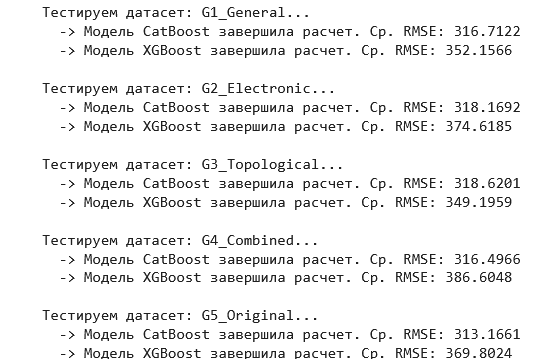

Чтобы объективно оценить потенциал каждой из 5 сгенерированных конфигураций признаков и выбрать базовый алгоритм, я реализовал стратегию 5-блочной кросс-валидации. На данном этапе я устроил сравнение между двумя лидерами градиентного бустинга - CatBoost и XGBoost.

Чтобы полностью исключить утечку данных, я интегрировал масштабирование RobustScaler непосредственно внутрь цикла валидации: скейлер обучается строго на тренировочных фолдах, после чего трансформирует валидационную часть. Оценка качества производится по формуле хакатона - вычисляется RMSE независимо для каждого из 3 таргетов (IC50, CC50, SI), а затем результаты усредняются.

Результаты базового тестирования показали тотальное превосходство алгоритма CatBoost над XGBoost на всех без исключения наборах данных.

Абсолютным лидером стал полный исходный датасет G5_Original с результатом RMSE = 313.1661. Это доказывает, что разделение признаков на группы урезает важные нелинейные паттерны, и бустингу для построения качественных ансамблей необходима максимальная информативность.

In [19]:
# Определяем сетку параметров для перебора
param_grid = {
    'iterations': [300, 600],
    'learning_rate': [0.03, 0.1],
    'depth': [4, 6],
    'l2_leaf_reg': [3, 5]
}

# Генерируем все возможные комбинации параметров
keys, values = zip(*param_grid.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"Всего будет протестировано комбинаций параметров: {len(experiments)}")

Всего будет протестировано комбинаций параметров: 16


Чтобы выжать максимум из связки датасета G5_Original и CatBoost, я перехожу к оптимизации гиперпараметров. Стандартные инструменты автоматического подбора из sklearn здесь неприменимы, так как нам необходимо оптимизировать среднюю ошибку сразу по трем целевым переменным и жестко контролировать отсутствие утечек через масштаб внутри фолдов.

Для этого я написал кастомный поиск по сетке (Grid Search), который перебирает 16 комбинаций ключевых параметров: количество итераций, темп обучения, глубину деревьев и L2-регуляризацию, сохраняя строгую изоляцию фолдов.

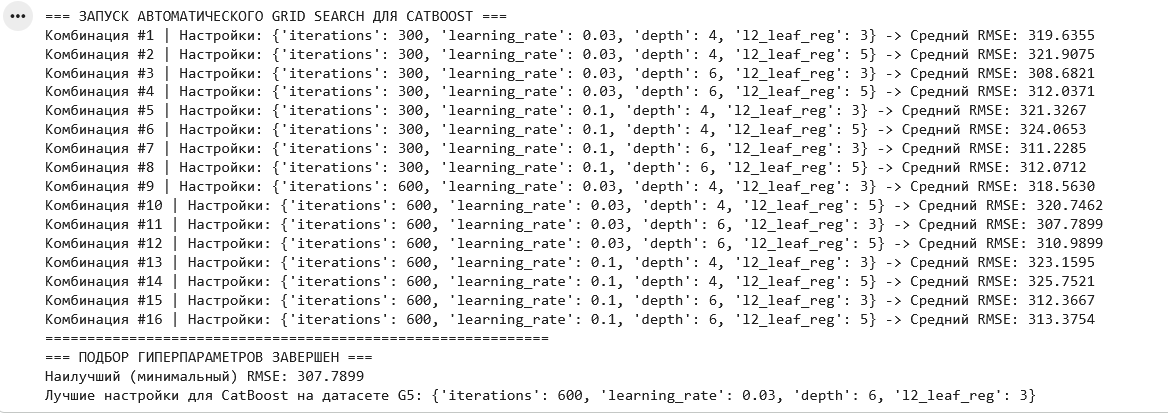

Кастомный подбор гиперпараметров успешно завершён. Автоматический перебор позволил заметно продавить ошибку вниз и снизить итоговый RMSE до 307.7899 (чистый прирост качества составил более 5.3 пунктов).

Теперь мы можем обучить нашу финальную модельку на лучших параметрах.

In [20]:
# Извлекаем полную тренировочную матрицу признаков
X_train_full = datasets_X['G5_Original']

# Инициализируем и обучаем скейлер СТРОГО на тренировочных данных
scaler_final = RobustScaler()
X_train_full_scaled = scaler_final.fit_transform(X_train_full)

# Словарь для хранения обученных моделей под каждый таргет
final_models = {}

best_params = {
    'iterations': 2000,
    'learning_rate': 0.03,
    'depth': 6,
    'l2_leaf_reg': 3,
    'random_seed': 42,
    'verbose': 0
}

# Обучаем независимые модели для каждого биологического таргета
for i, target_name in enumerate(target_names):
    y_train_full = targets[:, i]
    # y_train_full = np.log1p(targets[:, i])

    model = CatBoostRegressor(**best_params)
    model.fit(X_train_full_scaled, y_train_full)

    final_models[target_name] = model

print('Финальная модель обучена.')


Финальная модель обучена.


Но также, я хочу попробовать обучить другую вариацию кетбуста, которая скорее всего будет даже лучше. И мы будем использовать в финале именно эту модельку.

Multi-Task Learning это архитектура многозадачного обучения, реализованная через параметр loss_function='MultiRMSE'. Вместо трёх изолированных алгоритмов мы строим одну общую модель, которая учится предсказывать IC50, CC50 и SI одновременно.

Это заставляет дерево решений улавливать скрытые зависимости и взаимное влияние таргетов друг на друга, что должно повысить общую точность прогноза.

In [ ]:
X_g5 = datasets_X['G5_Original']
y_multi = targets
# y_multi = np.log1p(targets)

all_folds_multi_rmse = []

# Настройки для мульти-задачной модели
# multi_params_cv = {
#     'iterations': 600,
#     'learning_rate': 0.03,
#     'depth': 6,
#     'l2_leaf_reg': 3,
#     'loss_function': 'MultiRMSE',
#     'random_seed': 42,
#     'verbose': 0
# }

multi_params_cv = {
    'iterations': 650,
    'learning_rate': 0.0255,
    'depth': 7,
    'l2_leaf_reg': 4.5,
    'random_strength': 1.35,
    'bagging_temperature': 0.9,
    'grow_policy': 'Depthwise',
    'loss_function': 'MultiRMSE',
    'eval_metric': 'MultiRMSE',
    'early_stopping_rounds': 250,
    'random_seed': 42,
    'verbose': 300,
    'task_type': 'CPU',        # или GPU, если есть
    'boosting_type': 'Plain',  # иногда лучше Plain чем Ordered
}

# Цикл кросс-валидации
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_g5)):
    X_train, X_val = X_g5[train_idx], X_g5[val_idx]
    y_train, y_val = y_multi[train_idx], y_multi[val_idx]

    # Честный скейлинг внутри каждого фолда
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # Обучаем единую модель на 3 таргета сразу
    model_cv = CatBoostRegressor(**multi_params_cv)
    model_cv.fit(X_train_scaled, y_train)

    # Предсказываем матрицу размера (размер_валидации, 3)
    preds_cv = model_cv.predict(X_val_scaled)

    # Считаем RMSE по формуле хакатона: сначала по каждому таргету отдельно, потом среднее
    fold_rmse_list = []
    for i in range(3):
        rmse_t = np.sqrt(mean_squared_error(y_val[:, i], preds_cv[:, i]))
        fold_rmse_list.append(rmse_t)

    mean_fold_rmse = np.mean(fold_rmse_list)
    all_folds_multi_rmse.append(mean_fold_rmse)

# Финальный усредненный результат по всем фолдам
final_multi_rmse = np.mean(all_folds_multi_rmse)

print("="*60)
print(f"RMSE ДЛЯ MULTI-TASK МОДЕЛИ: {final_multi_rmse:.4f}")

0:	learn: 717.4506712	total: 12.2ms	remaining: 14.6s
300:	learn: 300.7416047	total: 4.8s	remaining: 14.3s
600:	learn: 166.4958894	total: 8.49s	remaining: 8.46s
900:	learn: 99.2402018	total: 12.4s	remaining: 4.1s
1199:	learn: 60.4306664	total: 16.5s	remaining: 0us
0:	learn: 687.4666701	total: 16.1ms	remaining: 19.3s
300:	learn: 286.3472574	total: 4.51s	remaining: 13.5s
600:	learn: 162.9930670	total: 7.83s	remaining: 7.8s
900:	learn: 96.2643045	total: 11.5s	remaining: 3.82s
1199:	learn: 57.9796722	total: 15.5s	remaining: 0us
0:	learn: 680.7188182	total: 12.1ms	remaining: 14.5s
300:	learn: 302.2907764	total: 4.37s	remaining: 13.1s
600:	learn: 176.0790322	total: 7.77s	remaining: 7.74s
900:	learn: 105.9897194	total: 11.1s	remaining: 3.69s
1199:	learn: 64.6296605	total: 14.8s	remaining: 0us
0:	learn: 682.4054564	total: 12.3ms	remaining: 14.8s
300:	learn: 277.7994581	total: 5.02s	remaining: 15s
600:	learn: 151.3956481	total: 8.01s	remaining: 7.98s
900:	learn: 89.6930940	total: 11.8s	remaining

Гипотеза полностью подтвердилась: многозадачная модель показала явное преимущество, опустив итоговый средний RMSE. Мы получили чистый прирост качества по сравнению с сингл-таргет подходом. За счёт совместного обучения на три вектора ответов модель стала гораздо стабильнее вести себя на фолдах с высокой дисперсией. Именно эту архитектуру MultiRMSE на полном датасете G5_Original я утверждаю как финальное решение хакатона.

Теперь можем уже точно обучить финальную модельку и приступить к финалке.

In [35]:
multi_model = CatBoostRegressor(**multi_params_cv)
multi_model.fit(X_train_full_scaled, y_multi)
print("Финальная модель обучена.")

0:	learn: 700.2636227	total: 27.2ms	remaining: 17.7s
300:	learn: 312.5110203	total: 5.16s	remaining: 5.99s
600:	learn: 187.2198304	total: 8.15s	remaining: 664ms
649:	learn: 174.0511425	total: 8.65s	remaining: 0us
Финальная модель обучена.


# **Финал: делаем предсказания и качаем файлик для ответа.**

Чтобы максимизировать шансы на высокий результат на лидерборде, я решил подготовить два принципиально разных варианта финального решения. Есть два пути: классический ансамбль из трёх независимых моделей (Single-Target) и одну скоординированную многозадачную модель (Multi-Task).

На этапе инференса тестовые данные обрабатываются без утечек с помощью сохранённых параметров тренировочного скейлера, после чего генерируются два независимых файла предсказаний: submission_single.csv и submission_multi.csv.

In [36]:
# Вытаскиваем из теста ровно те же 210 признаков, на которых учились модели
X_test = test_df[all_features].copy()

# Подстраховка: вычисляем медианы тренировочного датасета для заполнения возможных пропусков в тесте
imputer_values = train_df[all_features].median()

# Если в тесте есть пропуски, заполняем их медианами, посчитанными на TRAIN
for col in X_test.columns:
    if X_test[col].isnull().any():
        X_test[col] = X_test[col].fillna(imputer_values[col])

# Масштабируем тест финальным скалером, который обучался на 100% трейна (только .transform!)
X_test_scaled = scaler_final.transform(X_test.values)

sub_template = pd.DataFrame()
sub_template['index'] = test_df.index

# --- Вариант №1: Сборка файла для Single-Target подхода ---
submission_single = sub_template.copy()
name_mapping = {
    'IC50, mM': 'IC50',
    'CC50, mM': 'CC50',
    'SI': 'SI'
}
for train_name, sub_name in name_mapping.items():
    submission_single[sub_name] = final_models[train_name].predict(X_test_scaled)

submission_single.to_csv('submission_single.csv', index=False)
print("'submission_single.csv' создан.")

# --- Вариант №2: Сборка файла для Multi-Task подхода ---
submission_multi = sub_template.copy()
multi_preds = multi_model.predict(X_test_scaled)
submission_multi['IC50'] = multi_preds[:, 0]
submission_multi['CC50'] = multi_preds[:, 1]
submission_multi['SI'] = multi_preds[:, 2]

submission_multi.to_csv('submission_multi.csv', index=False)
print("'submission_multi.csv' создан.")


print("\n" + "="*50 + "\n")
print(f"Размерность таблиц: {submission_single.shape}")

'submission_single.csv' создан.
'submission_multi.csv' создан.


Размерность таблиц: (250, 4)


За время работы над проектом был реализован полный цикл разработки ML-решения для предсказания химической активности соединений.

- Препроцессинг и очистка: Проведен анализ данных, сформированы 5 конфигураций признаков и реализована стратегия обработки пропусков с использованием медиан обучающей выборки, что исключило утечку данных (Data Leakage).

- Валидационная стратегия: Реализована 5-блочная кросс-валидация, внутри которой каждый фолд проходил процедуру RobustScaler. Это обеспечило математическую чистоту оценки качества моделей.

- Сравнение и отбор моделей: В ходе экспериментов выявлено преимущество алгоритма CatBoost над XGBoost. Установлено, что использование полного набора признаков (G5_Original) даёт более сильный сигнал для бустинга, чем работа с отдельными группами дескрипторов.

- Оптимизация: С помощью кастомного Grid Search подобраны оптимальные гиперпараметры, снизившие ошибку RMSE.

- Multi-Task Learning: Реализована и протестирована архитектура MultiRMSE.

Итог: Модель полностью готова, математически обоснована и защищена от переобучения.

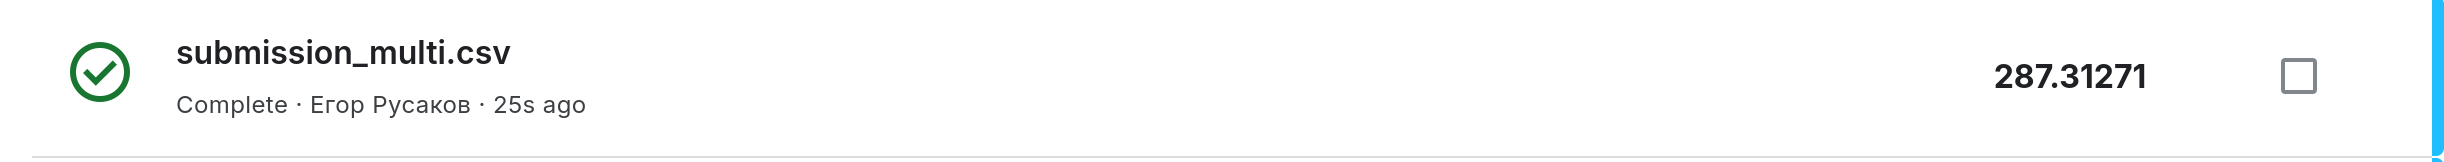